In [2]:
print("Alhamdullilah")

Alhamdullilah


In [11]:
import pandas as pd

df = pd.read_csv('data/bank_additional.csv')

print(df.isnull().sum())
print(df.shape)
print(df.dtypes)

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64
(41188, 21)
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: ob

In [13]:
# Understand the target
df['y'].value_counts(normalize=True) * 100

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

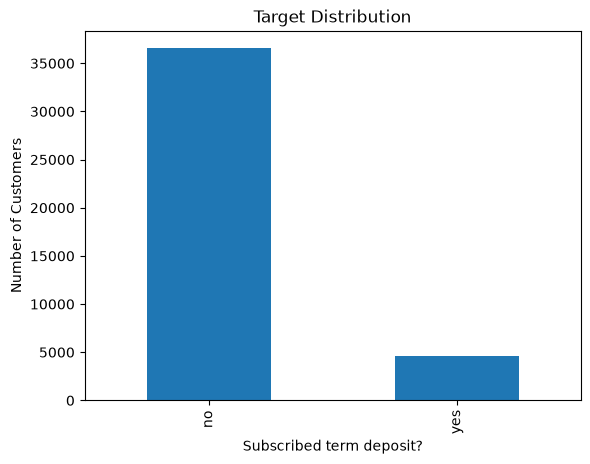

In [14]:
import matplotlib.pyplot as plt

df['y'].value_counts().plot(kind='bar')
plt.title('Target Distribution')
plt.xlabel("Subscribed term deposit?")
plt.ylabel("Number of Customers")
plt.show()

In [20]:
# Inspect missing/unknown values
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


job
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

marital
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

education
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

default
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

housing
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

loan
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

contact
contact
ce

/tmp/ipykernel_9463/2397928553.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [21]:
# Remove Leakage
df_model = df.drop(columns=["duration"]).copy()
df.dtypes

age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

In [22]:
# Separate X and y
X = df_model.drop(columns=["y"])
y = df_model['y'].map({
    "no": 0,
    "yes": 1
})

print(X.shape)
print(y.shape)

(41188, 19)
(41188,)


In [30]:
# Identify the feature types
categorical_features = X.select_dtypes(include=['object', 'str']).columns.tolist()
# print(categorical_features)
numerical_features = X.select_dtypes(exclude=['object', 'str']).columns.tolist()
print(numerical_features)

['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [31]:
from sklearn.model_selection import train_test_split
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    random_state=42,
    stratify=y
)

print("Train: ", X_train.shape)
print("Test:  ", X_test.shape)

print("\nTrain target: ")
print(y_train.value_counts(normalize=True))

print("\nTest target: ")
print(y_test.value_counts(normalize=True))

Train:  (30891, 19)
Test:   (10297, 19)

Train target: 
y
0    0.887346
1    0.112654
Name: proportion, dtype: float64

Test target: 
y
0    0.887346
1    0.112654
Name: proportion, dtype: float64


In [32]:
# Build preprocessing correctly
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [33]:
# Building first model - Logistic Regression
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [34]:
# Evaluate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

print("Accuracy : ", accuracy_score(y_test, y_pred))
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("F1 : ", f1_score(y_test, y_pred))
print("ROC-AUC : ", roc_auc_score(y_test, y_prob))
print("PR-AUC  : ", average_precision_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy :  0.8346120229192969
Precision :  0.36671575846833576
Recall :  0.6439655172413793
F1 :  0.4673131060369096
ROC-AUC :  0.8046835432289328
PR-AUC  :  0.4630322538259146

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      9137
           1       0.37      0.64      0.47      1160

    accuracy                           0.83     10297
   macro avg       0.66      0.75      0.68     10297
weighted avg       0.88      0.83      0.85     10297


Confusion Matrix:
[[7847 1290]
 [ 413  747]]
